# OpenFOAM run001_of13 convergence plots

This notebook plots residuals, continuity errors, and inlet/outlet flow rates for the OpenFOAM 13 run in this case directory.

In [1]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import pandas as pd

case_dir = Path.cwd()
log_file = case_dir / "log.foamRun.of13"
residual_file = case_dir / "postProcessing" / "residuals" / "0" / "residuals.dat"
inlet_flow_file = case_dir / "postProcessing" / "inletFlowRate" / "0" / "surfaceFieldValue.dat"
outlet_flow_file = case_dir / "postProcessing" / "outletFlowRate" / "0" / "surfaceFieldValue.dat"

for path in [log_file, residual_file, inlet_flow_file, outlet_flow_file]:
    if not path.exists():
        raise FileNotFoundError(path)

plt.rcParams.update({"figure.figsize": (8, 4.5), "axes.grid": True})

## Residuals

Residuals are read from `postProcessing/residuals/0/residuals.dat`.

In [2]:
def read_openfoam_table(path: Path) -> pd.DataFrame:
    header = None
    rows = []

    for raw_line in path.read_text().splitlines():
        line = raw_line.strip()
        if not line:
            continue

        if line.startswith("#"):
            if line.startswith("# Time"):
                header = line.lstrip("#").split()
            continue

        parts = line.split()
        if header and len(parts) == len(header):
            rows.append(parts)

    if header is None:
        raise ValueError(f"No '# Time' header found in {path}")

    df = pd.DataFrame(rows, columns=header)
    for col in df.columns:
        df[col] = pd.to_numeric(df[col].replace("N/A", pd.NA), errors="coerce")
    return df


residuals = read_openfoam_table(residual_file)
residuals.tail()

,Time,p,Ux,Uy
86,86,5.012895e-07,3.923131e-07,1.385824e-06
87,87,4.568247e-07,3.570490e-07,1.257459e-06
88,88,4.165206e-07,3.247735e-07,1.141409e-06
89,89,3.794952e-07,2.951591e-07,1.036000e-06
90,90,3.455592e-07,2.683682e-07,9.396691e-07


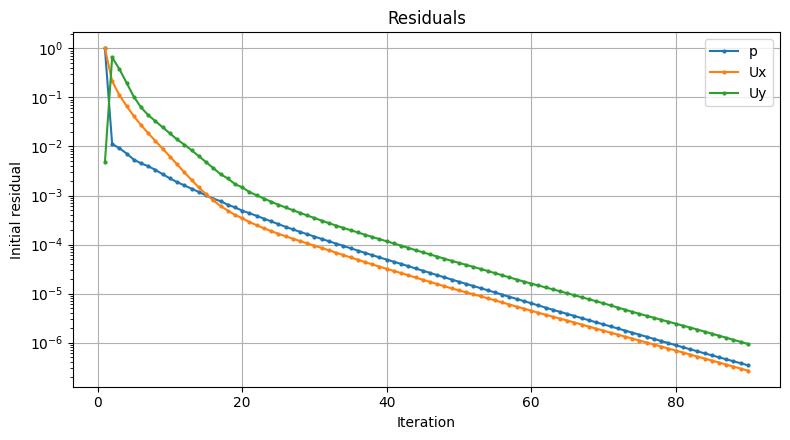

In [3]:
ax = residuals.set_index("Time").plot(marker="o", markersize=2)
ax.set_yscale("log")
ax.set_xlabel("Iteration")
ax.set_ylabel("Initial residual")
ax.set_title("Residuals")
plt.tight_layout()

## Continuity Errors

Continuity errors are parsed from `log.foamRun.of13` lines containing `time step continuity errors`.

In [4]:
def read_continuity_errors(path: Path) -> pd.DataFrame:
    time_re = re.compile(r"^Time = ([0-9.eE+-]+)s?")
    cont_re = re.compile(
        r"time step continuity errors\s*:\s*sum local = ([0-9.eE+-]+), "
        r"global = ([0-9.eE+-]+), cumulative = ([0-9.eE+-]+)"
    )
    current_time = None
    rows = []

    for line in path.read_text().splitlines():
        m_time = time_re.search(line.strip())
        if m_time:
            current_time = float(m_time.group(1))
            continue

        m_cont = cont_re.search(line)
        if m_cont:
            rows.append(
                {
                    "Time": current_time,
                    "sum_local": float(m_cont.group(1)),
                    "global": float(m_cont.group(2)),
                    "cumulative": float(m_cont.group(3)),
                }
            )

    return pd.DataFrame(rows)


continuity = read_continuity_errors(log_file)
continuity.tail()

,Time,sum_local,global,cumulative
85,86.0,1.299500e-08,1.081140e-09,0.000372
86,87.0,1.166280e-08,1.074080e-09,0.000372
87,88.0,1.055560e-08,1.009590e-09,0.000372
88,89.0,9.592460e-09,9.010860e-10,0.000372
89,90.0,8.738110e-09,7.625470e-10,0.000372


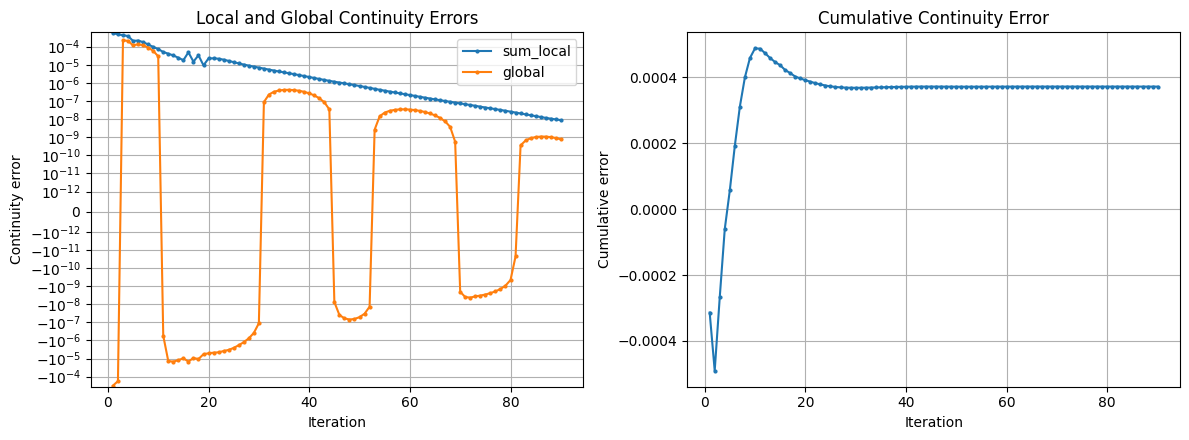

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

continuity.plot(x="Time", y=["sum_local", "global"], marker="o", markersize=2, ax=axes[0])
axes[0].set_yscale("symlog", linthresh=1e-12)
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("Continuity error")
axes[0].set_title("Local and Global Continuity Errors")

continuity.plot(x="Time", y="cumulative", marker="o", markersize=2, ax=axes[1], legend=False)
axes[1].set_xlabel("Iteration")
axes[1].set_ylabel("Cumulative error")
axes[1].set_title("Cumulative Continuity Error")

plt.tight_layout()

## Flow Rates

Flow rates are read from the `surfaceFieldValue` outputs for `phi` on `inlet` and `outlet`.

In [6]:
inlet_flow = read_openfoam_table(inlet_flow_file).rename(columns={"sum(phi)": "inlet_phi"})
outlet_flow = read_openfoam_table(outlet_flow_file).rename(columns={"sum(phi)": "outlet_phi"})

flow = pd.merge(inlet_flow, outlet_flow, on="Time", how="outer").sort_values("Time")
flow["net_phi"] = flow["inlet_phi"] + flow["outlet_phi"]
flow.tail()

,Time,inlet_phi,outlet_phi,net_phi
86,86,-0.000006,0.000006,0.0
87,87,-0.000006,0.000006,0.0
88,88,-0.000006,0.000006,0.0
89,89,-0.000006,0.000006,0.0
90,90,-0.000006,0.000006,0.0


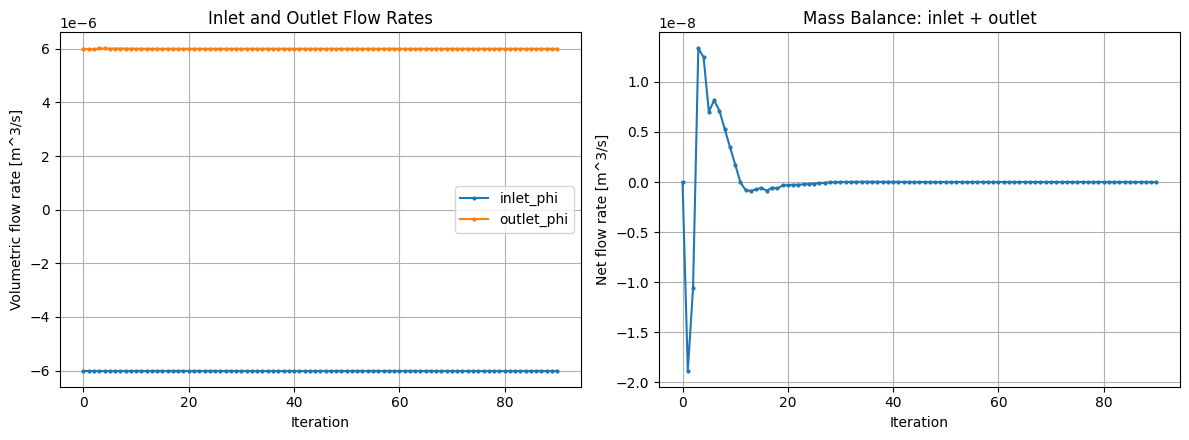

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

flow.plot(x="Time", y=["inlet_phi", "outlet_phi"], marker="o", markersize=2, ax=axes[0])
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("Volumetric flow rate [m^3/s]")
axes[0].set_title("Inlet and Outlet Flow Rates")

flow.plot(x="Time", y="net_phi", marker="o", markersize=2, ax=axes[1], legend=False)
axes[1].set_xlabel("Iteration")
axes[1].set_ylabel("Net flow rate [m^3/s]")
axes[1].set_title("Mass Balance: inlet + outlet")

plt.tight_layout()